In [ ]:
import pandas as pd
from shapely.geometry import Point
import requests
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
import os

In [ ]:
lsoa_to_station = pd.read_csv("../services/lsoa_station_map.csv")
stations_df = pd.read_csv("../services/metropolitan_police_stations.csv")

base_path = "../data/LB_shp"
shapefiles = glob.glob(os.path.join(base_path, "**/*.shp"), recursive=True)
lsoa_gdfs = [gpd.read_file(shp) for shp in shapefiles]
lsoa_london = gpd.GeoDataFrame(
    pd.concat(lsoa_gdfs, ignore_index=True),
    crs=lsoa_gdfs[0].crs
)

In [19]:
lsoa_map = lsoa_london.merge(
    lsoa_to_station,
    on="lsoa21cd",
    how="left"
)

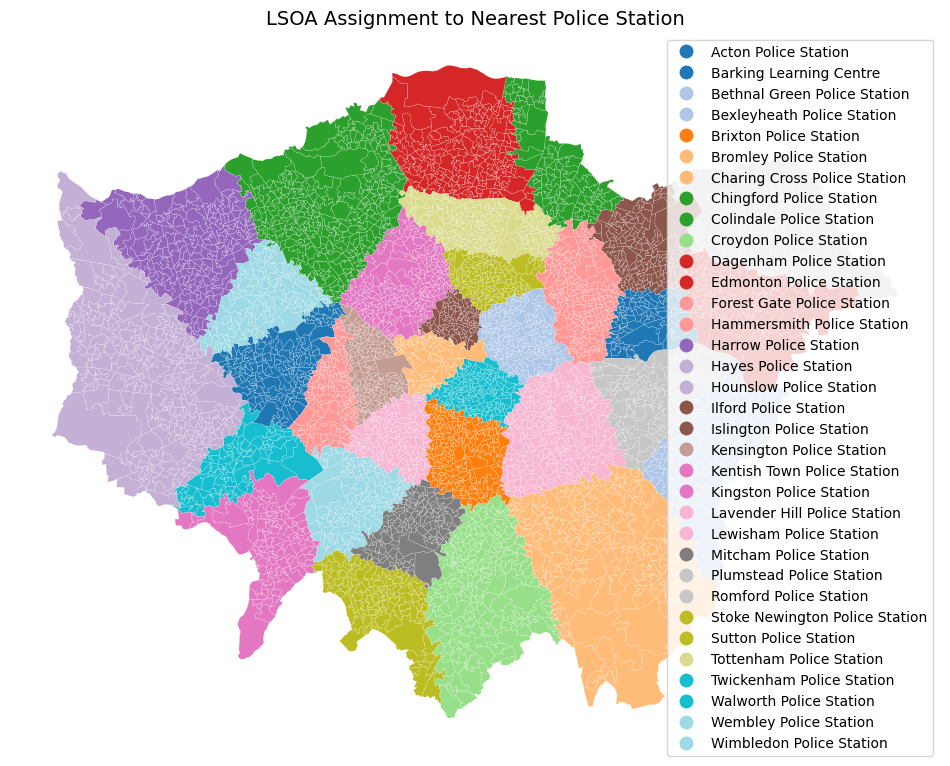

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

lsoa_map.plot(
    column="station",
    categorical=True,
    cmap="tab20",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("LSOA Assignment to Nearest Police Station", fontsize=14)
ax.axis("off")

plt.show()

stations_gdf.plot(
    ax=ax,
    color="black",
    markersize=20
)